In [1]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

card_df = pd.read_csv("../data/credit-card-fraud-detection/creditcard.csv")
card_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
card_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [3]:
# 컬럼별 결측치 개수
card_df.isna().sum().sum()

np.int64(0)

In [4]:
card_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [5]:
print(card_df[card_df["Class"]==1]["Class"].count())
print(card_df[card_df["Class"]==0]["Class"].count())

492
284315


In [6]:
# 분산 0인 컬럼 없음.
card_df.describe().loc["std",:].unique()

array([4.74881460e+04, 1.95869580e+00, 1.65130858e+00, 1.51625501e+00,
       1.41586857e+00, 1.38024673e+00, 1.33227109e+00, 1.23709360e+00,
       1.19435290e+00, 1.09863209e+00, 1.08884977e+00, 1.02071303e+00,
       9.99201390e-01, 9.95274230e-01, 9.58595611e-01, 9.15316012e-01,
       8.76252887e-01, 8.49337064e-01, 8.38176210e-01, 8.14040501e-01,
       7.70925025e-01, 7.34524014e-01, 7.25701560e-01, 6.24460296e-01,
       6.05647068e-01, 5.21278071e-01, 4.82227013e-01, 4.03632495e-01,
       3.30083264e-01, 2.50120109e+02, 4.15271896e-02])

In [7]:
# # Class와 다른 Features의 상관관계 파악.

# from matplotlib import pyplot as plt
# import seaborn as sns

# f, (ax1, ax2) = plt.subplots(2, 1, figsize=(24,20))

# # Entire DataFrame
# corr = card_df.corr()
# sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax1)
# ax1.set_title("Imbalanced Correlation Matrix \n (don't use for reference)", fontsize=14)


# sub_sample_corr = card_df.corr()
# sns.heatmap(sub_sample_corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax2)
# ax2.set_title('SubSample Correlation Matrix \n (use for reference)', fontsize=14)
# plt.show()

In [8]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, average_precision_score


def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix( y_test, pred)
    accuracy = accuracy_score(y_test , pred)
    precision = precision_score(y_test , pred)
    recall = recall_score(y_test , pred)
    f1 = f1_score(y_test,pred)
    # ROC-AUC 추가
    roc_auc = roc_auc_score(y_test, pred_proba)
    # AUPRC 추가
    auprc = average_precision_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    # ROC-AUC print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f},\
    \nF1: {3:.4f}, AUC:{4:.4f}, AUPRC:{5:.4f}'.format(accuracy, precision, recall, f1, roc_auc, auprc))


In [9]:
def get_model_train_eval(model, ftr_train=None, ftr_test=None, tgt_train=None, tgt_test=None):
    model.fit(ftr_train, tgt_train)
    pred = model.predict(ftr_test)
    pred_proba = model.predict_proba(ftr_test)[:, 1]
    get_clf_eval(tgt_test, pred, pred_proba)

In [10]:
# from sklearn.model_selection import train_test_split


# # 인자로 입력받은 DataFrame을 복사 한 뒤 Time 컬럼만 삭제하고 복사된 DataFrame 반환
# def get_preprocessed_df(df=None):
#     df_copy = df.copy()
#     df_copy.drop('Time', axis=1, inplace=True)
#     return df_copy

In [11]:
from sklearn.model_selection import train_test_split

# get_processed_df( )를 로그 변환하는 로직으로 변경. 이상치 제거는 분할 이후 train/test 각각에 적용.
def get_preprocessed_df(df=None):
    df_copy = df.copy()
    amount_n = np.log1p(df_copy['Amount'])
    df_copy.insert(0, 'Amount_Scaled', amount_n)
    df_copy.drop(['Time','Amount'], axis=1, inplace=True)
    return df_copy

In [12]:
import numpy as np


def get_outlier(df=None, column=None, weight=1.5):
    # fraud에 해당하는 column 데이터만 추출, 1/4 분위와 3/4 분위 지점을 np.percentile로 구함.
    fraud = df[df['Class']==1][column]
    quantile_25 = np.percentile(fraud.values, 25)
    quantile_75 = np.percentile(fraud.values, 75)
    # IQR을 구하고, IQR에 1.5를 곱하여 최대값과 최소값 지점 구함.
    iqr = quantile_75 - quantile_25
    iqr_weight = iqr * weight
    lowest_val = quantile_25 - iqr_weight
    highest_val = quantile_75 + iqr_weight
    # 최대값 보다 크거나, 최소값 보다 작은 값을 아웃라이어로 설정하고 DataFrame index 반환.
    outlier_index = fraud[(fraud < lowest_val) | (fraud > highest_val)].index
    return outlier_index
   

In [13]:
outlier_index = get_outlier(df=card_df, column='V14', weight=1.5)
print('이상치 데이터 인덱스:', outlier_index)


이상치 데이터 인덱스: Index([8296, 8615, 9035, 9252], dtype='int64')


In [14]:
# 사전 데이터 가공 후 학습과 테스트 데이터 세트를 반환하는 함수.
def get_train_test_dataset(df=None):
    # 인자로 입력된 DataFrame의 사전 데이터 가공이 완료된 복사 DataFrame 반환
    df_copy = get_preprocessed_df(df)
    # DataFrame의 맨 마지막 컬럼이 레이블, 나머지는 피처들
    X_features = df_copy.iloc[:, :-1]
    y_target = df_copy.iloc[:, -1]
    # train_test_split( )으로 학습과 테스트 데이터 분할. stratify=y_target으로 Stratified 기반 분할
    X_train, X_test, y_train, y_test = \
    train_test_split(X_features, y_target, test_size=0.3, random_state=42, stratify=y_target)

    # 분할 이후 train, test 각각에 대해 V14 이상치 제거
    train_df = pd.concat([X_train, y_train], axis=1)
    train_outlier_index = get_outlier(df=train_df, column='V14', weight=1.5)
    train_df = train_df.drop(train_outlier_index, axis=0)
    X_train = train_df.iloc[:, :-1]
    y_train = train_df.iloc[:, -1]

    test_df = pd.concat([X_test, y_test], axis=1)
    test_outlier_index = get_outlier(df=test_df, column='V14', weight=1.5)
    test_df = test_df.drop(test_outlier_index, axis=0)
    X_test = test_df.iloc[:, :-1]
    y_test = test_df.iloc[:, -1]

    # 학습과 테스트 데이터 세트 반환
    return X_train, X_test, y_train, y_test

In [15]:
from imblearn.over_sampling import SMOTE

def get_smote(X_train, y_train):
    smote = SMOTE(random_state=42)
    X_train_over, y_train_over = smote.fit_resample(X_train, y_train)

    X_train_over = pd.DataFrame(X_train_over, columns=X_train.columns)
    y_train_over = pd.Series(y_train_over, name='Class')

    over_new_df = pd.concat([X_train_over, y_train_over], axis=1)
    over_new_df = over_new_df.sample(frac=1, random_state=42).reset_index(drop=True)
    return over_new_df, X_train_over, y_train_over


In [16]:
def underSampling(X_train, y_train):
    train_df = pd.concat([X_train, y_train], axis=1)

    fraud = train_df[train_df['Class'] == 1]
    non_fraud = train_df[train_df['Class'] == 0].sample(n=len(fraud), random_state=42)

    under_train_df = pd.concat([fraud, non_fraud]).sample(frac=1, random_state=42)

    X_train_under = under_train_df.drop('Class', axis=1)
    y_train_under = under_train_df['Class']
    return under_train_df, X_train_under, y_train_under

In [17]:
from imblearn.combine import SMOTEENN

def get_smote_enn(X_train, y_train):
    smote_enn = SMOTEENN(random_state=42)
    X_train_enn, y_train_enn = smote_enn.fit_resample(X_train, y_train)

    X_train_enn = pd.DataFrame(X_train_enn, columns=X_train.columns)
    y_train_enn = pd.Series(y_train_enn, name='Class')

    enn_new_df = pd.concat([X_train_enn, y_train_enn], axis=1)
    enn_new_df = enn_new_df.sample(frac=1, random_state=42).reset_index(drop=True)
    return enn_new_df, X_train_enn, y_train_enn

In [18]:
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)

In [19]:
over_new_df, X_train_over, y_train_over = get_smote(X_train, y_train)
under_train_df, X_train_under, y_train_under = underSampling(X_train, y_train)
enn_new_df, X_train_enn, y_train_enn = get_smote_enn(X_train, y_train)

print('SMOTE 적용 전:', X_train.shape, y_train.shape)
print('SMOTE 적용 후:', X_train_over.shape, y_train_over.shape)
print('적용 후 레이블 분포:\n', over_new_df['Class'].value_counts())
print("------")
print('SMOTE-ENN 적용 전:', X_train.shape, y_train.shape)
print('SMOTE-ENN 적용 후:', X_train_enn.shape, y_train_enn.shape)
print('적용 후 레이블 분포:\n', y_train_enn.value_counts())
print("------")
print('RandomUnderSampling 적용 전:', X_train.shape, y_train.shape)
print('RandomUnderSampling 적용 후:', X_train_under.shape, y_train_under.shape)
print('적용 후 레이블 분포:\n', y_train_under.value_counts())

SMOTE 적용 전: (199362, 29) (199362,)
SMOTE 적용 후: (398040, 29) (398040,)
적용 후 레이블 분포:
 Class
0    199020
1    199020
Name: count, dtype: int64
------
SMOTE-ENN 적용 전: (199362, 29) (199362,)
SMOTE-ENN 적용 후: (397717, 29) (397717,)
적용 후 레이블 분포:
 Class
1    199020
0    198697
Name: count, dtype: int64
------
RandomUnderSampling 적용 전: (199362, 29) (199362,)
RandomUnderSampling 적용 후: (684, 29) (684,)
적용 후 레이블 분포:
 Class
0    342
1    342
Name: count, dtype: int64


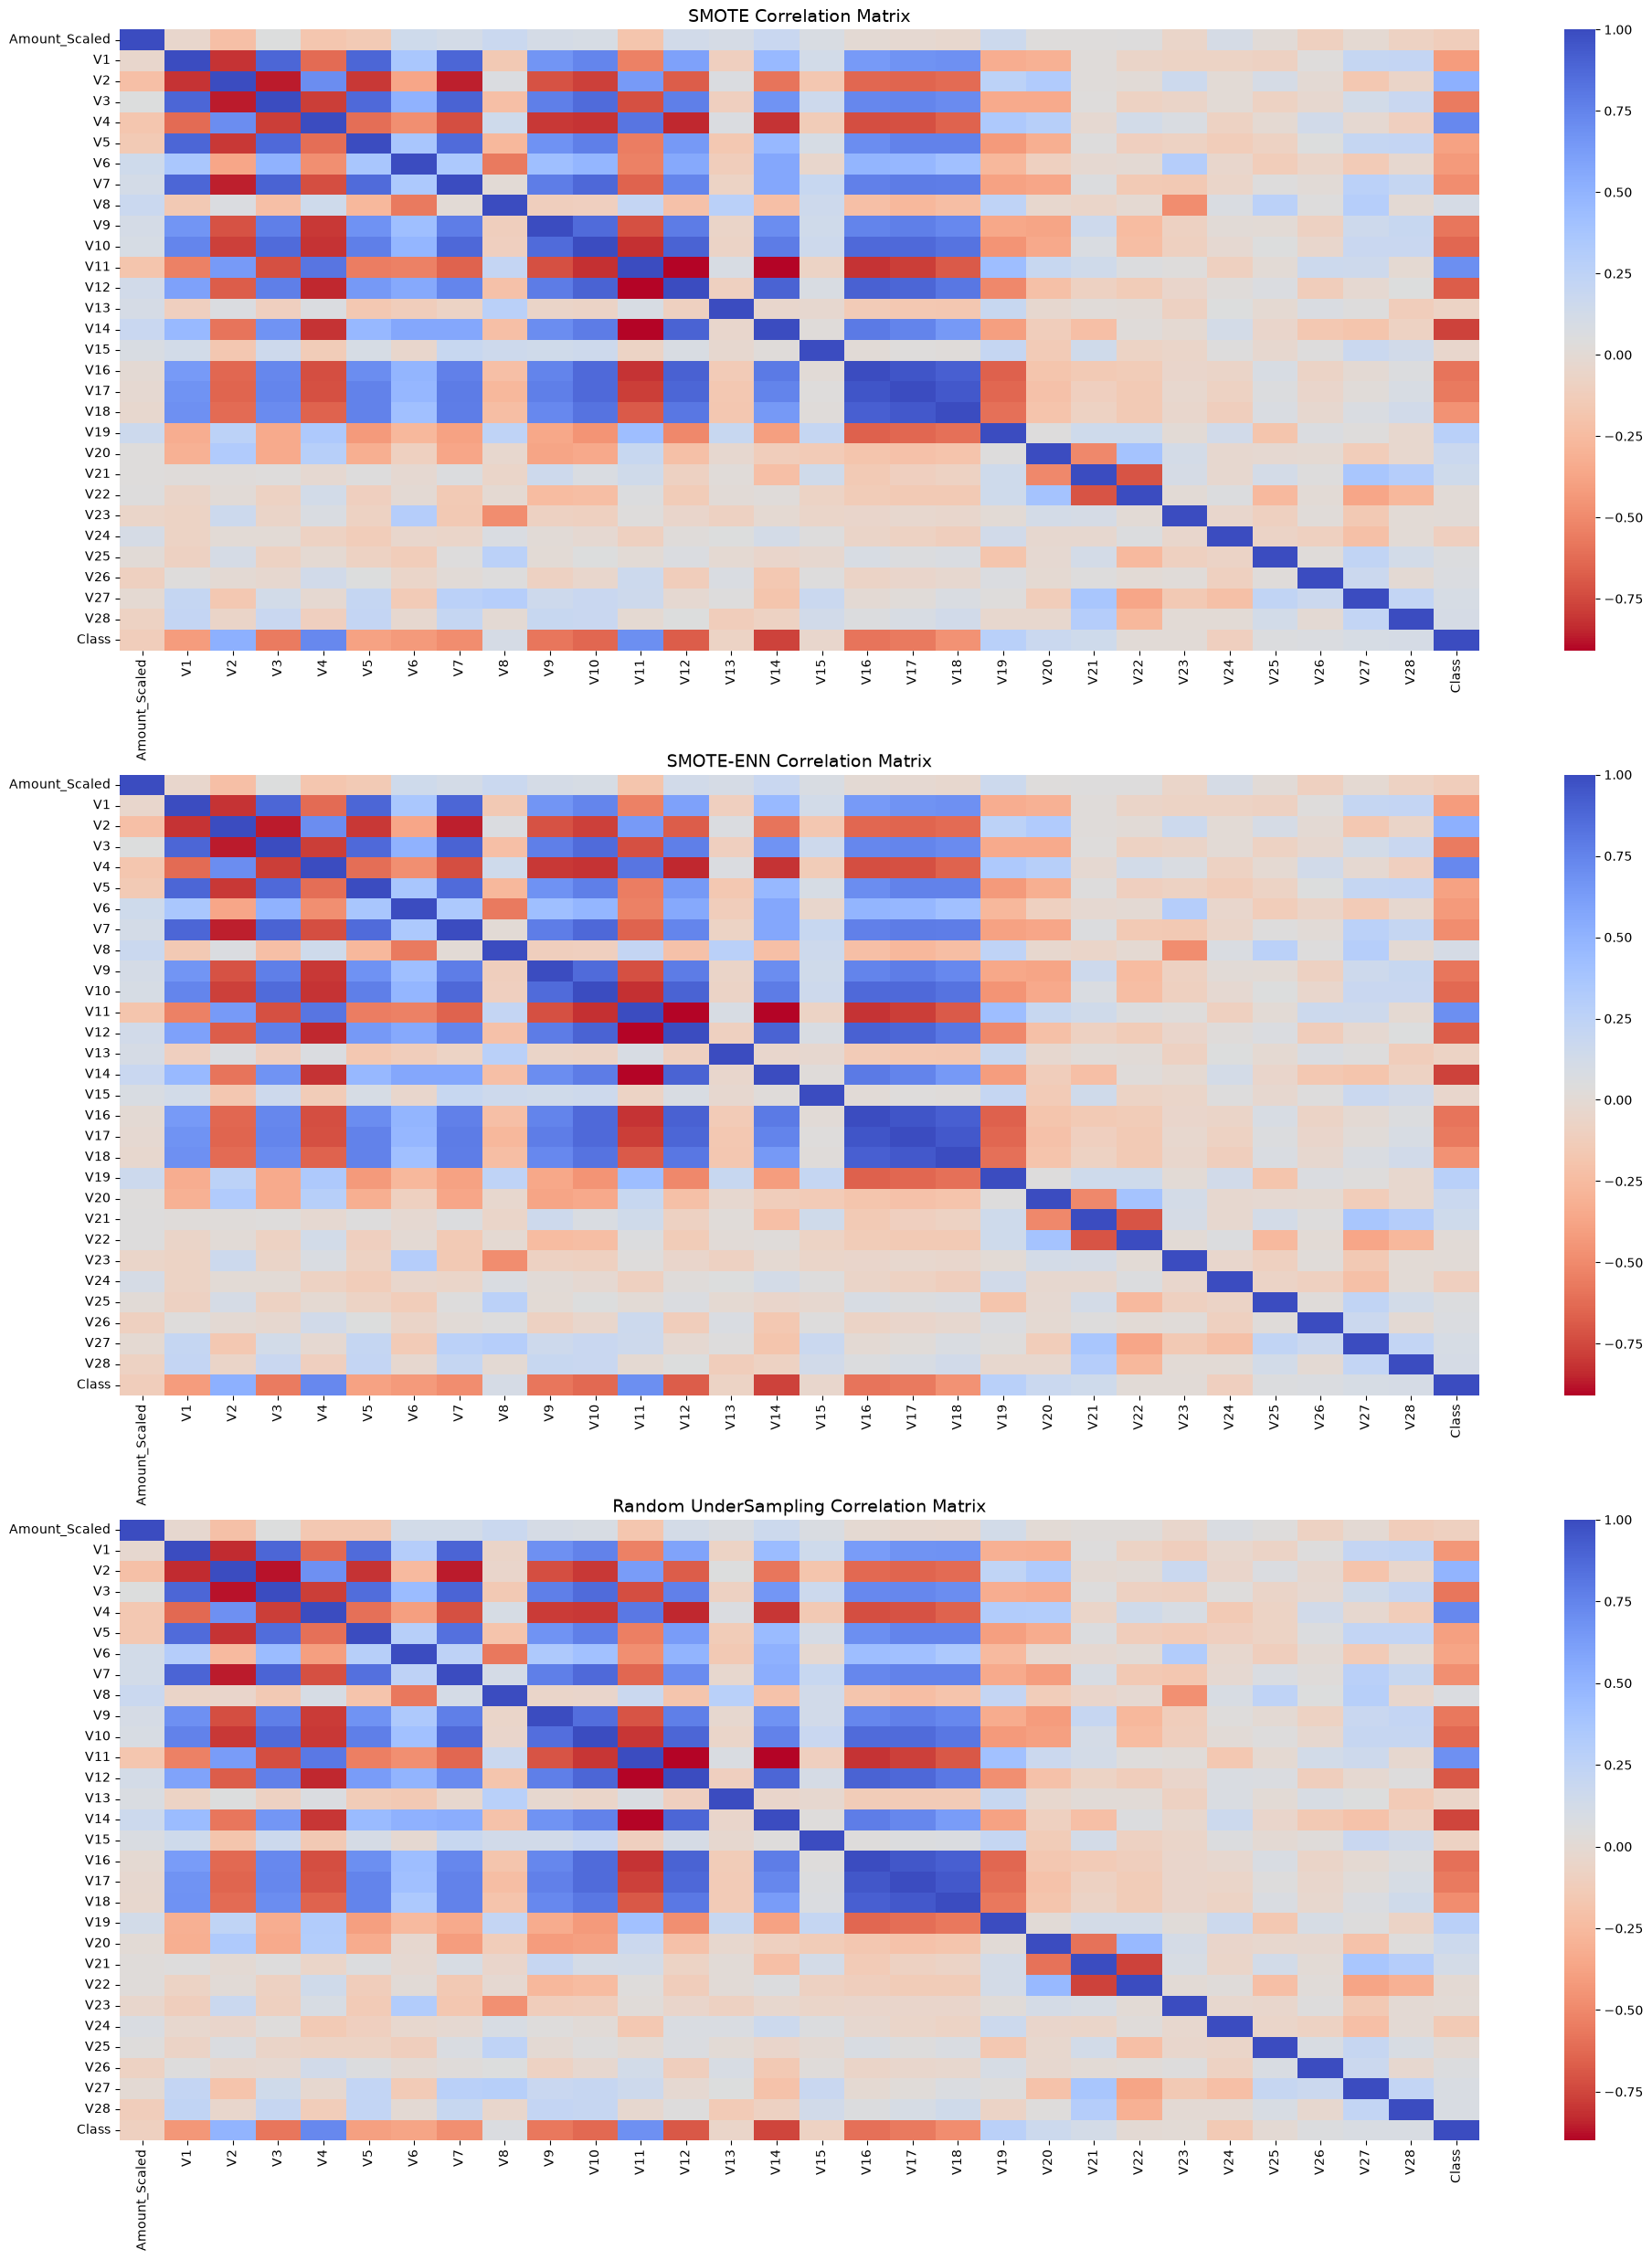

In [20]:
# Class와 다른 Features의 상관관계 파악.

from matplotlib import pyplot as plt
import seaborn as sns

f, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(24, 30))

# SMOTE
smote_corr = over_new_df.corr()
sns.heatmap(smote_corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax1)
ax1.set_title('SMOTE Correlation Matrix', fontsize=14)

# SMOTE-ENN
enn_corr = enn_new_df.corr()
sns.heatmap(enn_corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax2)
ax2.set_title('SMOTE-ENN Correlation Matrix', fontsize=14)

# Random UnderSampling
under_corr = under_train_df.corr()
sns.heatmap(under_corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax3)
ax3.set_title('Random UnderSampling Correlation Matrix', fontsize=14)

plt.show()

In [21]:
def get_model_train_eval(model, ftr_train=None, ftr_test=None, tgt_train=None, tgt_test=None):
    model.fit(ftr_train, tgt_train)
    pred = model.predict(ftr_test)
    pred_proba = model.predict_proba(ftr_test)[:, 1]
    get_clf_eval(tgt_test, pred, pred_proba)

In [22]:
from lightgbm import LGBMClassifier


lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False)
get_model_train_eval(lgbm_clf, ftr_train=X_train_under, ftr_test=X_test, tgt_train=y_train_under, tgt_test=y_test)
# get_model_train_eval(lgbm_clf, ftr_train=X_train_over, ftr_test=X_test, tgt_train=y_train_over, tgt_test=y_test)
# get_model_train_eval(lgbm_clf, ftr_train=X_train_enn, ftr_test=X_test, tgt_train=y_train_enn, tgt_test=y_test)

# 언더샘플링
# 오차 행렬
# [[82703  2592]
#  [   17   130]]
# 정확도: 0.9695, 정밀도: 0.0478, 재현율: 0.8844,    
# F1: 0.0906, AUC:0.9777, AUPRC:0.6689

# 오버샘플링(SMOTE)
# [[85278    17]
#  [   30   117]]
# 정확도: 0.9994, 정밀도: 0.8731, 재현율: 0.7959,    
# F1: 0.8327, AUC:0.9697, AUPRC:0.8274

# 오버샘플링(SMOTE-ENN)
# 오차 행렬
# [[85254    41]
#  [   27   120]]
# 정확도: 0.9992, 정밀도: 0.7453, 재현율: 0.8163,    
# F1: 0.7792, AUC:0.9739, AUPRC:0.8059


[LightGBM] [Info] Number of positive: 342, number of negative: 342
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000682 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6618
[LightGBM] [Info] Number of data points in the train set: 684, number of used features: 29
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

In [23]:
from sklearn.metrics import precision_recall_curve

# precision_recall_curve로 threshold를 스캔해서 F1이 가장 높은 지점을 찾는 함수
def scan_threshold(model, X_train, y_train, X_test, y_test, name=""):
    model.fit(X_train, y_train)
    pred_proba = model.predict_proba(X_test)[:, 1]

    precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba)
    f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-10)
    best_idx = np.argmax(f1_scores)

    print(f'[{name}] Best Threshold: {thresholds[best_idx]:.4f}, Precision: {precisions[best_idx]:.4f}, Recall: {recalls[best_idx]:.4f}, F1: {f1_scores[best_idx]:.4f}')
    return thresholds[best_idx], precisions[best_idx], recalls[best_idx], f1_scores[best_idx]


lgbm_smote = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False)
lgbm_enn = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False)

scan_threshold(lgbm_smote, X_train_over, y_train_over, X_test, y_test, name='SMOTE')
scan_threshold(lgbm_enn, X_train_enn, y_train_enn, X_test, y_test, name='SMOTE-ENN')

[LightGBM] [Info] Number of positive: 199020, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019991 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 398040, number of used features: 29
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

(np.float64(0.9989691149627563),
 np.float64(0.8357142857142857),
 np.float64(0.7959183673469388),
 np.float64(0.8153310104029915))

In [103]:
from sklearn.model_selection import StratifiedKFold

# 하이퍼파라미터 튜닝용 교차검증 전략: 클래스 비율을 유지하며 5-fold 분할
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 하이퍼파라미터 튜닝 기준 지표: 불균형 데이터라 accuracy 대신 AUPRC(average_precision) 사용.
# threshold 조정은 튜닝 이후 별도로 진행할 것이므로, threshold에 의존하지 않는 지표로 SMOTE와 SMOTE-ENN을 비교.
scoring = 'average_precision'

In [108]:
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline

param_grid = {
    'classifier__num_leaves': [31, 64],
    'classifier__max_depth': [-1, 7],
    'classifier__learning_rate': [0.05, 0.1]
}

# 파이프라인으로 감싸서 매 CV 폴드의 학습 데이터에만 SMOTE 적용 (검증 폴드는 원본 그대로 유지 -> 누수 방지)
smote_pipeline = ImbPipeline([
    ('sampler', SMOTE(random_state=42)),
    ('classifier', LGBMClassifier(n_estimators=1000, n_jobs=1, boost_from_average=False))
])

lgbm_smote_grid = GridSearchCV(
    smote_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)
lgbm_smote_grid.fit(X_train, y_train)

# 동일하게 SMOTE-ENN도 파이프라인으로 감싸서 매 CV 폴드 학습 데이터에만 적용
enn_pipeline = ImbPipeline([
    ('sampler', SMOTEENN(random_state=42)),
    ('classifier', LGBMClassifier(n_estimators=1000, n_jobs=1, boost_from_average=False))
])

lgbm_enn_grid = GridSearchCV(
    enn_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)
lgbm_enn_grid.fit(X_train, y_train)

print('[SMOTE] Best Params:', lgbm_smote_grid.best_params_)
print('[SMOTE] Best CV AUPRC:', lgbm_smote_grid.best_score_)
print('[SMOTE-ENN] Best Params:', lgbm_enn_grid.best_params_)
print('[SMOTE-ENN] Best CV AUPRC:', lgbm_enn_grid.best_score_)

[LightGBM] [Info] Number of positive: 199020, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.075964 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 398040, number of used features: 29
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

In [106]:
# GridSearchCV의 best_estimator_(전체 학습 데이터로 재학습된 모델)를 그대로 사용.
# X_test는 SMOTE를 거치지 않은 실제 홀드아웃 데이터라 여기 평가는 CV AUPRC와 달리 신뢰할 수 있음.
print('=== SMOTE (Best Params) ===')
pred_smote = lgbm_smote_grid.best_estimator_.predict(X_test)
pred_proba_smote = lgbm_smote_grid.best_estimator_.predict_proba(X_test)[:, 1]
get_clf_eval(y_test, pred_smote, pred_proba_smote)

print('\n=== SMOTE-ENN (Best Params) ===')
pred_enn = lgbm_enn_grid.best_estimator_.predict(X_test)
pred_proba_enn = lgbm_enn_grid.best_estimator_.predict_proba(X_test)[:, 1]
get_clf_eval(y_test, pred_enn, pred_proba_enn)

=== SMOTE (Best Params) ===
오차 행렬
[[84668   627]
 [   30   117]]
정확도: 0.9923, 정밀도: 0.1573, 재현율: 0.7959,    
F1: 0.2626, AUC:0.9012, AUPRC:0.1402

=== SMOTE-ENN (Best Params) ===
오차 행렬
[[85250    45]
 [   24   123]]
정확도: 0.9992, 정밀도: 0.7321, 재현율: 0.8367,    
F1: 0.7810, AUC:0.9704, AUPRC:0.7821


In [ ]:
# 커널을 새로 켠 상태라 GridSearchCV를 다시 돌리지 않고,
# 이전에 찾은 Best Params를 그대로 반영해 재학습/평가.
#
# [SMOTE] Best Params: {'classifier__learning_rate': 0.05, 'classifier__max_depth': -1, 'classifier__num_leaves': 64}
# [SMOTE] Best CV AUPRC: 0.8673070095628652
# [SMOTE-ENN] Best Params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 7, 'classifier__num_leaves': 31}
# [SMOTE-ENN] Best CV AUPRC: 0.8522498147989148

lgbm_smote_best = LGBMClassifier(
    n_estimators=1000, n_jobs=-1, boost_from_average=False,
    learning_rate=0.05, max_depth=-1, num_leaves=64
)
lgbm_enn_best = LGBMClassifier(
    n_estimators=1000, n_jobs=-1, boost_from_average=False,
    learning_rate=0.1, max_depth=7, num_leaves=31
)

print('=== SMOTE (Best Params) ===')
get_model_train_eval(lgbm_smote_best, ftr_train=X_train_over, ftr_test=X_test, tgt_train=y_train_over, tgt_test=y_test)

print('\n=== SMOTE-ENN (Best Params) ===')
get_model_train_eval(lgbm_enn_best, ftr_train=X_train_enn, ftr_test=X_test, tgt_train=y_train_enn, tgt_test=y_test)

# SMOTE
# 오차 행렬
# [[85278    17]
#  [   30   117]]
# 정확도: 0.9994, 정밀도: 0.8731, 재현율: 0.7959,    
# F1: 0.8327, AUC:0.9720, AUPRC:0.8342

# SMOTE-ENN
# 오차 행렬
# [[85256    39]
#  [   24   123]]
# 정확도: 0.9993, 정밀도: 0.7593, 재현율: 0.8367,    
# F1: 0.7961, AUC:0.9745, AUPRC:0.8113


=== SMOTE (Best Params) ===
[LightGBM] [Info] Number of positive: 199020, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018551 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 398040, number of used features: 29
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM